In [1]:
#!/usr/bin/env python
# coding: utf-8

# Standard library imports
import itertools
from itertools import product
#import logging
import multiprocessing
import os
import shutil
import sys
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Iterable, Tuple

# Third-party imports
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.widgets  # Cursor
import numpy as np
import pandas as pd
import polars as pl
import scipy.integrate
import scipy.ndimage.interpolation
from concurrent.futures import ThreadPoolExecutor
from sklearn.metrics import mean_squared_error

### Load and Compose all the `CSVs`

In [2]:
def read_csv_file_with_fips(file_path):
    # Extract the folder name (fips) from the path
    fips = int(os.path.basename(os.path.dirname(file_path)))
    
    # Read the CSV into a Polars DataFrame
    df = pl.read_csv(file_path)
    
    # Add a 'fips' column with the extracted value
    df = df.with_columns(pl.lit(fips).cast(pl.Int32).alias("fips"))
    
    return df

# Function to gather all CSV file paths
def collect_csv_files(base_dir):
    csv_files = []
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.csv'):
                file_path = os.path.join(root, file)
                csv_files.append(file_path)
    return csv_files

# Main function to read CSVs in parallel and add FIPS
def read_all_csvs_in_parallel_with_fips(base_dir):
    # Gather all CSV file paths
    csv_files = collect_csv_files(base_dir)
    
    # Read all CSV files in parallel, with the fips column
    with ThreadPoolExecutor() as executor:
        # Map the file paths to the function in parallel
        dataframes = list(executor.map(read_csv_file_with_fips, csv_files))

    # Concatenate all the DataFrames into one
    if dataframes:
        combined_df = pl.concat(dataframes)
        return combined_df
    else:
        return None


In [3]:
sim_results_folder = "./sim_results"

In [4]:
combined_df = read_all_csvs_in_parallel_with_fips(sim_results_folder)
if 'date' in combined_df.columns:
    combined_df = combined_df.with_columns(pl.col("date").str.strptime(pl.Date, "%Y-%m-%d"))  # Assuming date format is "YYYY-MM-DD"

# Rearrange columns so 'fips' and 'date' come first
new_column_order = ["fips", "date"] + [col for col in combined_df.columns if col not in ["fips", "date"]]
combined_df = combined_df.select(new_column_order).sort(["fips","date"])
combined_df.write_csv("simulated_colorado_SEIR.csv")

In [5]:
combined_df.schema

OrderedDict([('fips', Int32),
             ('date', Date),
             ('S', Float64),
             ('E', Float64),
             ('I', Float64),
             ('R', Float64),
             ('rolled_cases', Float64),
             ('R0', Float64)])

### Load Changepoints DataFrame

In [6]:
changepoints = pl.read_csv("~/experimental-COVID-tracking/case_study/data/CDPHE_TLGRF_historical_filtered.csv")
changepoints = changepoints.with_columns(pl.col("fips").cast(pl.Int32).alias("fips"))
changepoints = changepoints.with_columns(pl.col("date.x").str.strptime(pl.Date, "%Y-%m-%d"))


In [7]:
SEIR_R0 = combined_df.select(["fips","date","R0"])

In [8]:
changepoints_w_R0 = changepoints.join(SEIR_R0, left_on=["fips","date.x"], right_on=["fips","date"], how="left")

In [9]:
changepoints_w_R0.schema

OrderedDict([('datetime_x', Utf8),
             ('fips', Int32),
             ('changepoint', Float64),
             ('outbreak', Int64),
             ('capacity', Float64),
             ('county_x', Utf8),
             ('state_x', Utf8),
             ('date.x', Date),
             ('weekly new cases', Float64),
             ('days_from_start', Float64),
             ('log_rolled_cases.x.x', Float64),
             ('t0.hat', Float64),
             ('tau.hat', Float64),
             ('predicted.grf.future', Float64),
             ('predicted.grf.future.0', Float64),
             ('predicted.grf.future.last', Float64),
             ('Predicted_Double_Days', Float64),
             ('predicted.grf.past', Float64),
             ('predicted.grf.past.0', Float64),
             ('predicted.grf.past.last', Float64),
             ('log_rolled_cases.x.y', Float64),
             ('block.mse', Float64),
             ('block new cases', Float64),
             ('block.mse.0', Float64),
             (

In [10]:
changepoints_w_R0

datetime_x,fips,changepoint,outbreak,capacity,county_x,state_x,date.x,weekly new cases,days_from_start,log_rolled_cases.x.x,t0.hat,tau.hat,predicted.grf.future,predicted.grf.future.0,predicted.grf.future.last,Predicted_Double_Days,predicted.grf.past,predicted.grf.past.0,predicted.grf.past.last,log_rolled_cases.x.y,block.mse,block new cases,block.mse.0,block.mse.last,block.mae,block.mae.0,block.mae.last,block.mape,block.mape.0,block.mape.last,log_rolled_cases.x,date,county_y,state_y,cases,deaths,…,F_AGE65,F_AGE17,F_DISABL,F_SNGPNT,F_THEME2,F_MINRTY,F_LIMENG,F_THEME3,F_MUNIT,F_MOBILE,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP,log_rolled_cases,shifted_log_rolled_cases,delta cases,delta_ranked,TLGRF_predictor,TLGRF_predictor_rank,TLGRF_decision,P,N,CDPHE_TP,TLGRF_TP,CDPHE_FP,TLGRF_FP,CDPHE_FN,TLGRF_FN,CDPHE_TN,TLGRF_TN,R0
str,i32,f64,i64,f64,str,str,date,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f64
"""2020-10-19""",8003,0.0,0,1.0,"""Alamosa""","""Colorado""",2020-10-19,20.0,272.0,3.509411,225.732268,0.084999,4.527718,4.104722,4.104406,8.154744,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""2020-10-19""","""Alamosa""","""Colorado""",43.0,9.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,3.509411,3.923387,17.142857,4.0,2.841404,2.0,0,false,true,false,false,false,false,false,false,true,true,2.941812
"""2020-10-20""",8003,1.0,1,1.0,"""Alamosa""","""Colorado""",2020-10-20,23.0,273.0,3.599267,223.360822,0.079745,4.516665,4.147367,4.157479,8.692097,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""2020-10-20""","""Alamosa""","""Colorado""",46.0,9.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,3.599267,3.948493,15.285714,3.0,2.916371,1.0,1,false,true,false,false,true,true,false,false,false,false,3.012242
"""2021-04-04""",8003,0.0,0,1.0,"""Alamosa""","""Colorado""",2021-04-04,9.0,439.0,3.443162,547.77689,-0.030302,3.084045,3.232209,3.231047,-22.874621,2.940266,3.301478,3.285081,3.767823,0.252904,-12.0,0.020074,0.024989,0.502895,0.141683,0.15808,0.146056,0.041149,0.045911,null,"""2021-04-04""","""Alamosa""","""Colorado""",26.0,29.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,3.443162,3.555348,3.714286,7.0,-0.94802,10.0,0,false,true,false,false,false,false,false,false,true,true,0.33534
"""2021-04-06""",8003,0.0,0,1.0,"""Alamosa""","""Colorado""",2021-04-06,12.0,441.0,3.3771,549.169944,-0.030109,3.04608,3.16508,3.16634,-23.021606,2.846931,3.143357,3.137701,3.599267,0.281079,-7.285714,0.054636,0.057312,0.530169,0.233743,0.239399,0.156989,0.069214,0.070889,null,"""2021-04-06""","""Alamosa""","""Colorado""",26.0,29.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,3.3771,3.754533,13.428571,2.0,-0.88175,10.0,0,false,true,false,false,false,false,false,false,true,true,0.377607
"""2021-04-07""",8003,1.0,1,1.0,"""Alamosa""","""Colorado""",2021-04-07,8.0,442.0,3.327089,508.940437,-0.046537,2.789458,3.004803,3.001329,-14.894489,2.979098,3.211066,3.211582,3.551258,0.121098,-7.0,0.013461,0.013342,0.347991,0.116024,0.115508,0.104593,0.034872,0.034717,null,"""2021-04-07""","""Alamosa""","""Colorado""",26.0,29.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2237.0,14.0,3.0,16662.0,3.327089,3.847103,19.0,2.0,-1.296392,9.0,0,false,true,false,false,true,false,false,false,false,true,0.05053
"""2021-07-12""",8003,0.0,0,1.0,"""Alamosa""","""Colorado""",2021-07-12,16.0,538.0,3.420066,464.836362,0.049396,3.959762,3.757525,3.765838,14.032459,2.954309,3.008526,3.010176,3.110336,0.21693,8.142857,0.169365,0.16801,0.465757,0.41154,0.40989,0.136184,0.120331,0.119849,null,""

In [11]:
ranked_df = (
    changepoints_w_R0
    .with_columns([
        # Step 3: Rank R0 within each date.x group, with the highest value getting rank 1
        pl.col("R0").rank(method="dense", descending=True).over("date.x").alias("R0_rank")
    ])
)

In [12]:
# Only look at R0 of counties chosen by TLGRF or CDPHE
ranked_changepoints_R0 = ranked_df.filter(~pl.col("R0").is_null()).filter( (pl.col("TLGRF_decision")==1) | (pl.col("changepoint")==1))

In [22]:
subset_ranked_changepoints_R0 = ranked_changepoints_R0.select(["fips","date.x","county_x","days_from_start","tau.hat","capacity","changepoint","TLGRF_decision","TLGRF_predictor_rank","TLGRF_TP","TLGRF_FP","CDPHE_TP","CDPHE_FP","R0","R0_rank"])

In [23]:
subset_ranked_changepoints_R0.schema

OrderedDict([('fips', Int32),
             ('date.x', Date),
             ('county_x', Utf8),
             ('days_from_start', Float64),
             ('tau.hat', Float64),
             ('capacity', Float64),
             ('changepoint', Float64),
             ('TLGRF_decision', Int64),
             ('TLGRF_predictor_rank', Float64),
             ('TLGRF_TP', Boolean),
             ('TLGRF_FP', Boolean),
             ('CDPHE_TP', Boolean),
             ('CDPHE_FP', Boolean),
             ('R0', Float64),
             ('R0_rank', UInt32)])

In [24]:
subset_ranked_changepoints_R0

fips,date.x,county_x,days_from_start,tau.hat,capacity,changepoint,TLGRF_decision,TLGRF_predictor_rank,TLGRF_TP,TLGRF_FP,CDPHE_TP,CDPHE_FP,R0,R0_rank
i32,date,str,f64,f64,f64,f64,i64,f64,bool,bool,bool,bool,f64,u32
8003,2020-10-20,"""Alamosa""",273.0,0.079745,1.0,1.0,1,1.0,false,true,false,true,3.012242,2
8003,2021-04-07,"""Alamosa""",442.0,-0.046537,1.0,1.0,0,9.0,false,false,false,true,0.05053,13
8003,2021-08-30,"""Alamosa""",587.0,-0.003395,2.0,1.0,0,22.0,false,false,false,true,0.951472,22
8003,2022-05-18,"""Alamosa""",848.0,0.027911,2.0,1.0,0,14.0,false,false,false,true,1.645285,11
8003,2022-09-21,"""Alamosa""",974.0,-0.01262,1.0,1.0,0,11.0,false,false,true,false,0.745897,8
8007,2020-12-01,"""Archuleta""",315.0,0.062213,2.0,1.0,1,2.0,true,false,true,false,2.415685,2
8007,2021-01-26,"""Archuleta""",371.0,-0.010053,1.0,1.0,0,9.0,false,false,false,true,0.790927,9
8007,2021-03-03,"""Archuleta""",407.0,0.037286,1.0,1.0,0,3.0,false,false,false,true,1.709425,1
8007,2021-05-04,"""Archuleta""",469.0,-0.011883,2.0,1.0,0,10.0,false,false,false,true,0.759084,8


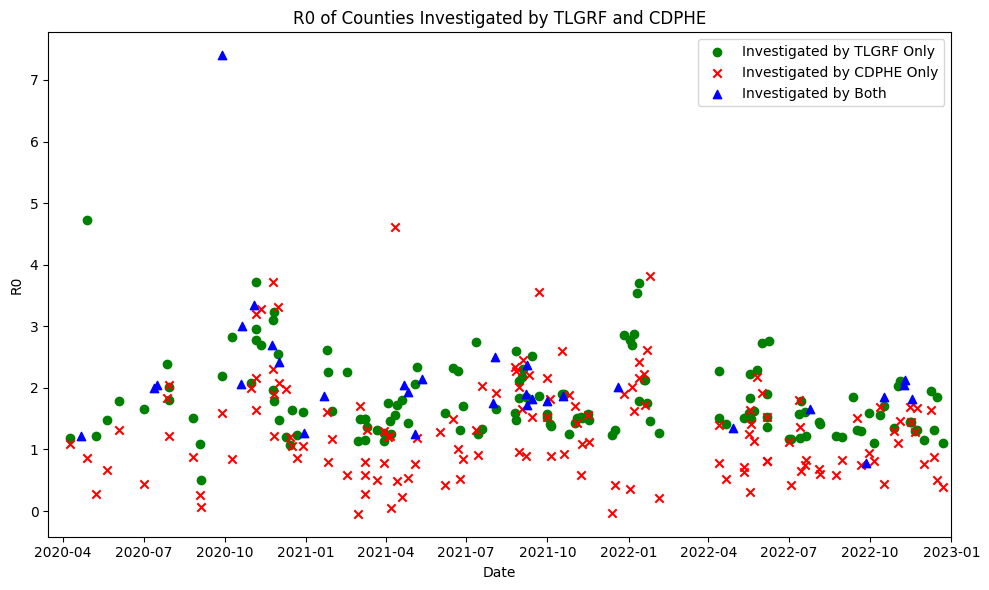

In [19]:
# Filter for points with TLGRF_decision == 1
df_decision_1 = subset_ranked_changepoints_R0.filter((pl.col("TLGRF_decision") == 1) & (pl.col("changepoint")==0))

# Filter for points with TLGRF_decision == 0 and changepoint == 1
df_changepoint_1 = subset_ranked_changepoints_R0.filter((pl.col("TLGRF_decision") == 0) & (pl.col("changepoint") == 1))

df_both_1 = subset_ranked_changepoints_R0.filter((pl.col("TLGRF_decision") == 1) & (pl.col("changepoint") == 1))


# Extract data for plotting
x_decision_1 = df_decision_1['date.x'].to_list()
y_decision_1 = df_decision_1['R0'].to_list()

x_changepoint_1 = df_changepoint_1['date.x'].to_list()
y_changepoint_1 = df_changepoint_1['R0'].to_list()

x_both_1 = df_both_1['date.x'].to_list()
y_both_1 = df_both_1['R0'].to_list()

# Create the plot
plt.figure(figsize=(10, 6))

# Plot "X" for TLGRF_decision == 1
plt.scatter(x_decision_1, y_decision_1, color='green', marker='o', label='Investigated by TLGRF Only')

# Plot "O" for TLGRF_decision == 0 and changepoint == 1
plt.scatter(x_changepoint_1, y_changepoint_1, color='red', marker='x', label='Investigated by CDPHE Only')

# Plot "^" for TLGRF_decision == 0 and changepoint == 1
plt.scatter(x_both_1, y_both_1, color='blue', marker='^', label='Investigated by Both')


# Label the axes
plt.xlabel('Date')
plt.ylabel('R0')
plt.title('R0 of Counties Investigated by TLGRF and CDPHE')

# Show legend
plt.legend()

# Rotate x-axis labels for better readability
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))

# Show the plot
plt.tight_layout()
plt.savefig("R0_Investigated.png")

plt.show()


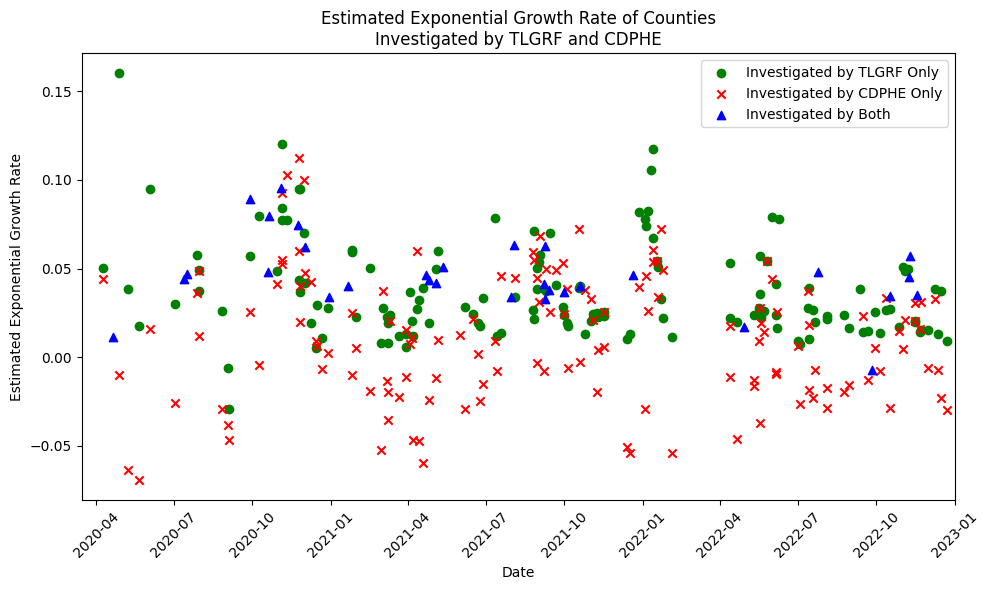

In [26]:
# Filter for points with TLGRF_decision == 1
df_decision_1 = subset_ranked_changepoints_R0.filter((pl.col("TLGRF_decision") == 1) & (pl.col("changepoint")==0))

# Filter for points with TLGRF_decision == 0 and changepoint == 1
df_changepoint_1 = subset_ranked_changepoints_R0.filter((pl.col("TLGRF_decision") == 0) & (pl.col("changepoint") == 1))

df_both_1 = subset_ranked_changepoints_R0.filter((pl.col("TLGRF_decision") == 1) & (pl.col("changepoint") == 1))


# Extract data for plotting
x_decision_1 = df_decision_1['date.x'].to_list()
y_decision_1 = df_decision_1['tau.hat'].to_list()

x_changepoint_1 = df_changepoint_1['date.x'].to_list()
y_changepoint_1 = df_changepoint_1['tau.hat'].to_list()

x_both_1 = df_both_1['date.x'].to_list()
y_both_1 = df_both_1['tau.hat'].to_list()

# Create the plot
plt.figure(figsize=(10, 6))

# Plot "X" for TLGRF_decision == 1
plt.scatter(x_decision_1, y_decision_1, color='green', marker='o', label='Investigated by TLGRF Only')

# Plot "O" for TLGRF_decision == 0 and changepoint == 1
plt.scatter(x_changepoint_1, y_changepoint_1, color='red', marker='x', label='Investigated by CDPHE Only')

# Plot "^" for TLGRF_decision == 0 and changepoint == 1
plt.scatter(x_both_1, y_both_1, color='blue', marker='^', label='Investigated by Both')


# Label the axes
plt.xlabel('Date')
plt.ylabel('Estimated Exponential Growth Rate')
plt.title('Estimated Exponential Growth Rate of Counties\nInvestigated by TLGRF and CDPHE')

# Show legend
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)
plt.xlim(pd.to_datetime('2020-03-15'), pd.to_datetime('2023-01-01'))

# Show the plot
plt.tight_layout()
plt.show()
